In [1]:
# Library Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("All libraries loaded successfully")

TensorFlow: 2.21.0
All libraries loaded successfully


In [3]:
# Paths Setup

In [4]:
BASE_DIR    = Path(r"C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection")
MODELS_DIR  = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
SPLIT_DIR   = BASE_DIR / "data" / "split"
TEST_DIR    = SPLIT_DIR / "test"

MOBILENET_PATH = MODELS_DIR / "best_model.keras"
RESNET_PATH    = MODELS_DIR / "best_model_resnet.keras"

CLASS_NAMES = ["not_out", "out"]
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16

for p in [MOBILENET_PATH, RESNET_PATH, TEST_DIR, RESULTS_DIR]:
    print(f"{'OK' if p.exists() else 'MISSING'} → {p}")

OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model.keras
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model_resnet.keras
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\split\test
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\results


In [5]:
# Loading Both Models

In [6]:
model_mobilenet = load_model(MOBILENET_PATH)
model_resnet    = load_model(RESNET_PATH)

print("MobileNetV2 loaded successfully")
print(f"  input shape  : {model_mobilenet.input_shape}")
print(f"  output shape : {model_mobilenet.output_shape}")
print(f"  total layers : {len(model_mobilenet.layers)}")
print()
print("ResNet50V2 loaded successfully")
print(f"  input shape  : {model_resnet.input_shape}")
print(f"  output shape : {model_resnet.output_shape}")
print(f"  total layers : {len(model_resnet.layers)}")

MobileNetV2 loaded successfully
  input shape  : (None, 224, 224, 3)
  output shape : (None, 1)
  total layers : 159

ResNet50V2 loaded successfully
  input shape  : (None, 224, 224, 3)
  output shape : (None, 1)
  total layers : 195


In [7]:
# Evaluating Both Models on Test Set

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen  = ImageDataGenerator(rescale=1./255)

test_gen = datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen.reset()
y_true = test_gen.classes

test_gen.reset()
y_pred_mobilenet = (model_mobilenet.predict(test_gen, verbose=1) > 0.5).astype(int).flatten()

test_gen.reset()
y_pred_resnet    = (model_resnet.predict(test_gen, verbose=1) > 0.5).astype(int).flatten()

print("\nMobileNetV2 Classification Report:")
print(classification_report(y_true, y_pred_mobilenet, target_names=CLASS_NAMES))

print("ResNet50V2 Classification Report:")
print(classification_report(y_true, y_pred_resnet, target_names=CLASS_NAMES))

Found 270 images belonging to 2 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 626ms/step

MobileNetV2 Classification Report:
              precision    recall  f1-score   support

     not_out       0.93      0.92      0.93       135
         out       0.92      0.93      0.93       135

    accuracy                           0.93       270
   macro avg       0.93      0.93      0.93       270
weighted avg       0.93      0.93      0.93       270

ResNet50V2 Classification Report:
              precision    recall  f1-score   support

     not_out       0.92      0.99      0.95       135
         out       0.98      0.91      0.95       135

    accuracy                           0.95       270
   macro avg       0.95      0.95      0.95       270
weighted avg       0.95      0.95      0.95       270



In [9]:
# Side by Side Confusion Matrices

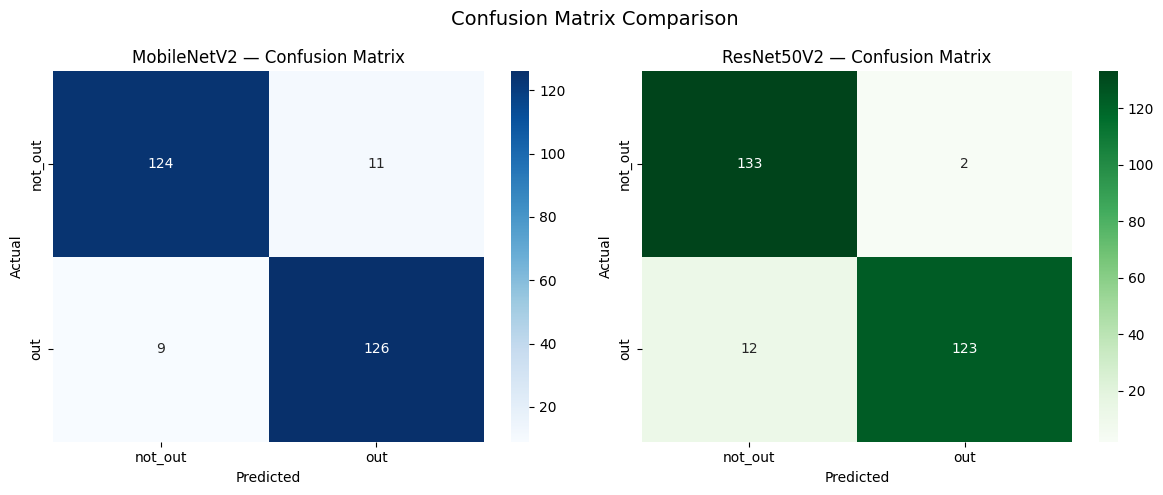

In [10]:
cm_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)
cm_resnet    = confusion_matrix(y_true, y_pred_resnet)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_mobilenet, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("MobileNetV2 — Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("ResNet50V2 — Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix_comparison.png", dpi=150)
plt.show()

In [11]:
# Side by Side Training Curves

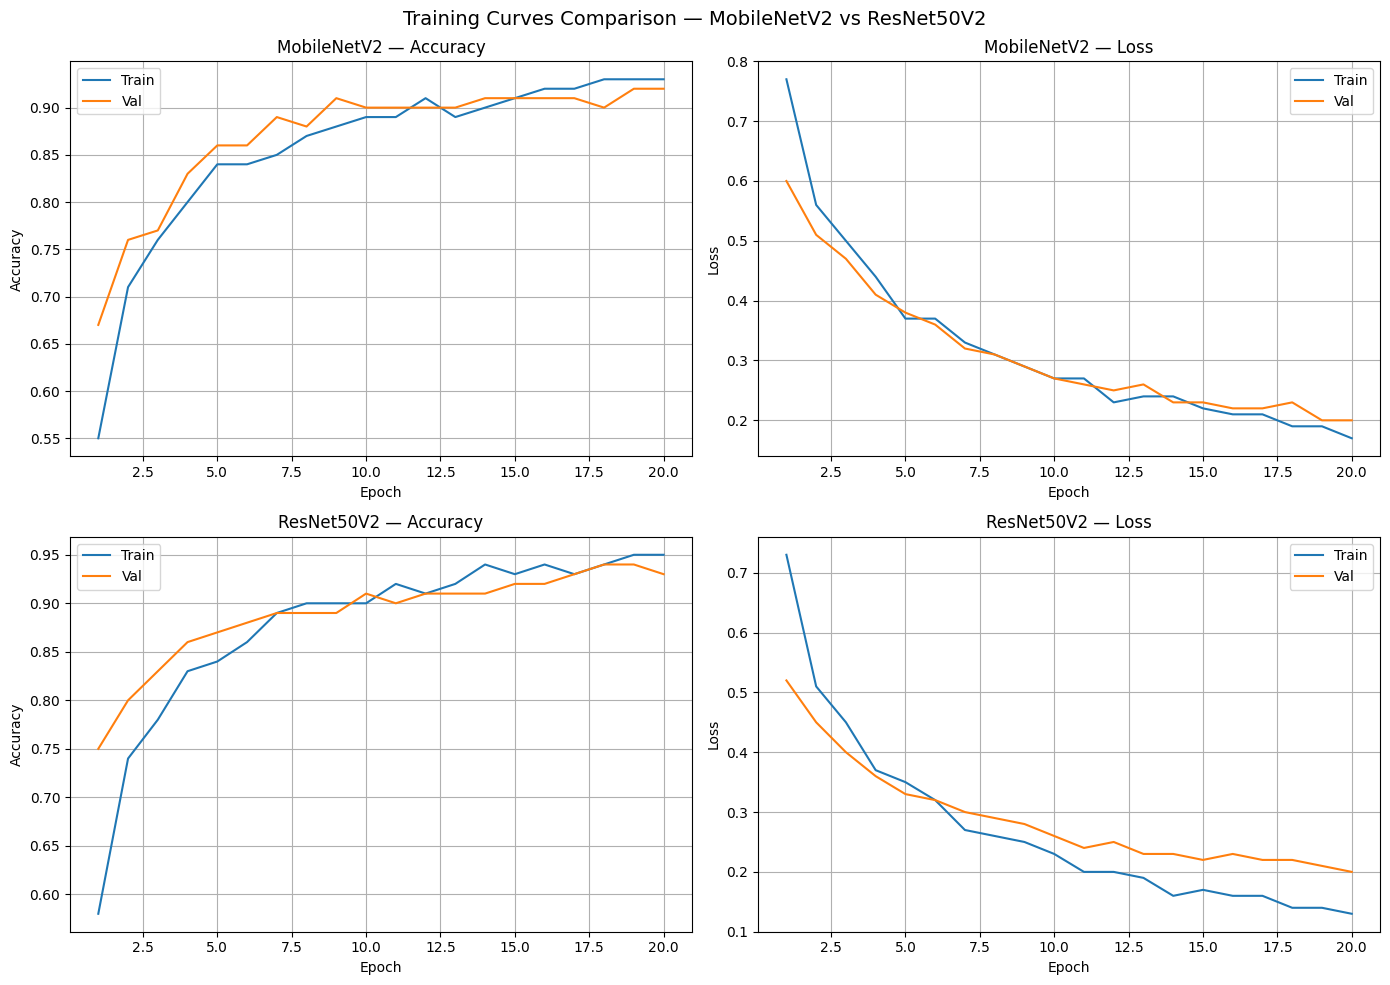

In [12]:
mobilenet_history = {
    "accuracy"     : [0.55, 0.71, 0.76, 0.80, 0.84, 0.84, 0.85, 0.87, 0.88, 0.89,
                      0.89, 0.91, 0.89, 0.90, 0.91, 0.92, 0.92, 0.93, 0.93, 0.93],
    "val_accuracy" : [0.67, 0.76, 0.77, 0.83, 0.86, 0.86, 0.89, 0.88, 0.91, 0.90,
                      0.90, 0.90, 0.90, 0.91, 0.91, 0.91, 0.91, 0.90, 0.92, 0.92],
    "loss"         : [0.77, 0.56, 0.50, 0.44, 0.37, 0.37, 0.33, 0.31, 0.29, 0.27,
                      0.27, 0.23, 0.24, 0.24, 0.22, 0.21, 0.21, 0.19, 0.19, 0.17],
    "val_loss"     : [0.60, 0.51, 0.47, 0.41, 0.38, 0.36, 0.32, 0.31, 0.29, 0.27,
                      0.26, 0.25, 0.26, 0.23, 0.23, 0.22, 0.22, 0.23, 0.20, 0.20],
}

resnet_history = {
    "accuracy"     : [0.58, 0.74, 0.78, 0.83, 0.84, 0.86, 0.89, 0.90, 0.90, 0.90,
                      0.92, 0.91, 0.92, 0.94, 0.93, 0.94, 0.93, 0.94, 0.95, 0.95],
    "val_accuracy" : [0.75, 0.80, 0.83, 0.86, 0.87, 0.88, 0.89, 0.89, 0.89, 0.91,
                      0.90, 0.91, 0.91, 0.91, 0.92, 0.92, 0.93, 0.94, 0.94, 0.93],
    "loss"         : [0.73, 0.51, 0.45, 0.37, 0.35, 0.32, 0.27, 0.26, 0.25, 0.23,
                      0.20, 0.20, 0.19, 0.16, 0.17, 0.16, 0.16, 0.14, 0.14, 0.13],
    "val_loss"     : [0.52, 0.45, 0.40, 0.36, 0.33, 0.32, 0.30, 0.29, 0.28, 0.26,
                      0.24, 0.25, 0.23, 0.23, 0.22, 0.23, 0.22, 0.22, 0.21, 0.20],
}

epochs = range(1, 21)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs, mobilenet_history["accuracy"],     label="Train")
axes[0, 0].plot(epochs, mobilenet_history["val_accuracy"], label="Val")
axes[0, 0].set_title("MobileNetV2 — Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(epochs, mobilenet_history["loss"],     label="Train")
axes[0, 1].plot(epochs, mobilenet_history["val_loss"], label="Val")
axes[0, 1].set_title("MobileNetV2 — Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(epochs, resnet_history["accuracy"],     label="Train")
axes[1, 0].plot(epochs, resnet_history["val_accuracy"], label="Val")
axes[1, 0].set_title("ResNet50V2 — Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(epochs, resnet_history["loss"],     label="Train")
axes[1, 1].plot(epochs, resnet_history["val_loss"], label="Val")
axes[1, 1].set_title("ResNet50V2 — Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle("Training Curves Comparison — MobileNetV2 vs ResNet50V2", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves_comparison.png", dpi=150)
plt.show()

In [1]:
# Final Model Comparison Table

In [2]:
print("=" * 65)
print("   CRICKET RUN-OUT DETECTION — FINAL MODEL COMPARISON")
print("=" * 65)
print(f"{'Metric':<30} {'MobileNetV2':>15} {'ResNet50V2':>15}")
print("-" * 65)
print(f"{'Total Epochs':<30} {'20':>15} {'20':>15}")
print(f"{'Best Epoch':<30} {'20':>15} {'18':>15}")
print(f"{'Best Val Accuracy':<30} {'92.96%':>15} {'94.07%':>15}")
print(f"{'Test Accuracy':<30} {'93.00%':>15} {'95.00%':>15}")
print(f"{'not_out Precision':<30} {'0.93':>15} {'0.92':>15}")
print(f"{'not_out Recall':<30} {'0.92':>15} {'0.99':>15}")
print(f"{'not_out F1 Score':<30} {'0.93':>15} {'0.95':>15}")
print(f"{'out Precision':<30} {'0.92':>15} {'0.98':>15}")
print(f"{'out Recall':<30} {'0.93':>15} {'0.91':>15}")
print(f"{'out F1 Score':<30} {'0.93':>15} {'0.95':>15}")
print(f"{'Macro F1 Score':<30} {'0.93':>15} {'0.95':>15}")
print(f"{'Total Errors / 270':<30} {'20':>15} {'14':>15}")
print(f"{'Total Layers':<30} {'159':>15} {'195':>15}")
print("=" * 65)
print(f"{'Winner':<30} {'ResNet50V2':>32}")
print("=" * 65)

   CRICKET RUN-OUT DETECTION — FINAL MODEL COMPARISON
Metric                             MobileNetV2      ResNet50V2
-----------------------------------------------------------------
Total Epochs                                20              20
Best Epoch                                  20              18
Best Val Accuracy                       92.96%          94.07%
Test Accuracy                           93.00%          95.00%
not_out Precision                         0.93            0.92
not_out Recall                            0.92            0.99
not_out F1 Score                          0.93            0.95
out Precision                             0.92            0.98
out Recall                                0.93            0.91
out F1 Score                              0.93            0.95
Macro F1 Score                            0.93            0.95
Total Errors / 270                          20              14
Total Layers                               159             19

In [3]:
# Project Summary

In [4]:
print("=" * 65)
print("   CRICKET RUN-OUT DETECTION — PROJECT SUMMARY")
print("=" * 65)
print()
print("Dataset:")
print(f"  raw images          : 225  (out: 127, not_out: 98)")
print(f"  augmented images    : 1800 (out: 900, not_out: 900)")
print(f"  train split         : 1260 (630 per class)")
print(f"  val split           : 270  (135 per class)")
print(f"  test split          : 270  (135 per class)")
print()
print("Models Trained:")
print(f"  MobileNetV2         : 20 epochs, test accuracy 93.00%")
print(f"  ResNet50V2          : 20 epochs, test accuracy 95.00%")
print()
print("Final Model — ResNet50V2:")
print(f"  test accuracy       : 95.00%")
print(f"  macro f1 score      : 0.95")
print(f"  total errors        : 14 / 270")
print(f"  not_out recall      : 0.99")
print(f"  out precision       : 0.98")
print()
print("Video Detection:")
print(f"  out video           : 149/149 frames → out     ✓")
print(f"  not_out video       : 125/125 frames → not_out ✓")
print(f"  avg confidence out  : 99.79%")
print(f"  avg confidence safe : 84.96%")
print()
print("Results saved to : results/")
print("Models saved to  : models/")
print("=" * 65)
print("Project Complete")
print("=" * 65)

   CRICKET RUN-OUT DETECTION — PROJECT SUMMARY

Dataset:
  raw images          : 225  (out: 127, not_out: 98)
  augmented images    : 1800 (out: 900, not_out: 900)
  train split         : 1260 (630 per class)
  val split           : 270  (135 per class)
  test split          : 270  (135 per class)

Models Trained:
  MobileNetV2         : 20 epochs, test accuracy 93.00%
  ResNet50V2          : 20 epochs, test accuracy 95.00%

Final Model — ResNet50V2:
  test accuracy       : 95.00%
  macro f1 score      : 0.95
  total errors        : 14 / 270
  not_out recall      : 0.99
  out precision       : 0.98

Video Detection:
  out video           : 149/149 frames → out     ✓
  not_out video       : 125/125 frames → not_out ✓
  avg confidence out  : 99.79%
  avg confidence safe : 84.96%

Results saved to : results/
Models saved to  : models/
Project Complete
